# Imports

In [42]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from torch.utils.data import Dataset
from torch.optim import AdamW
from transformers import DataCollatorForLanguageModeling
import matplotlib.pyplot as plt
from transformers import BertTokenizer, BertModel
import torch
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import re
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.model_selection import RepeatedStratifiedKFold
from scipy import stats

# Datasets preparation

In [22]:
df_ref = pd.read_csv("files/df_ml_good_with_features.csv")

df_ref_amy = df_ref[df_ref['class'] == 1]
df_ref_nonamy = df_ref[df_ref['class'] == 0]

df_protgpt2 = pd.read_csv("./files/final_datasets/protgpt_final.csv")
df_cvae = pd.read_csv("./files/final_datasets/cvae_final.csv")
df_diff = pd.read("./files/final_datasets/diff_final.csv")

In [23]:
selected_features = ['beta_propensity', 'proline_fraction', 'AAT', 'net_charge', 'TA', 'polar_fraction', 'a3vSA']

## Train/Test spilt

In [24]:
X_real = df_ref[selected_features]
y_real = df_ref["class"]

X_train_ref, X_test, y_train_ref, y_test = train_test_split(
    X_real, y_real,
    test_size=0.2,
    random_state=42,
    stratify=y_real
)

In [25]:
df_protgpt2['class'] = 1
df_cvae['class'] = 1

train_datasets = {
    "Real Only": (X_train_ref, y_train_ref),
    "Real + ProtGPT2": (
        pd.concat([X_train_ref, df_protgpt2[selected_features]]),
        pd.concat([y_train_ref, df_protgpt2["class"]])
    ),
    "Real + cVAE": (
        pd.concat([X_train_ref, df_cvae[selected_features]]),
        pd.concat([y_train_ref, df_cvae["class"]])
    ),
    "Real + Diff": (
        pd.concat([X_train_ref, df_diff[selected_features]]),
        pd.concat([y_train_ref, df_diff["class"]])
    )
}

In [31]:
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

# Models

## Baseline

In [27]:
models = {
    "RandomForest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    )
}

In [28]:
param_grids = {
    "RandomForest": {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    },
    "XGBoost": {
        'n_estimators': [100, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 6],
        'subsample': [0.8, 1.0]
    },
    "LogisticRegression": {
        'C': [0.01, 0.1, 1.0, 10.0],
        'solver': ['lbfgs', 'liblinear'], # liblinear powinien byc dobry dla malych zbiorów
        'penalty': ['l2']
    }
}

In [33]:
results_stat = []

for data_name, (X_train_curr, y_train_curr) in train_datasets.items():
    print("\n" + "=" * 80)
    print(f">>> Eksperyment dla zbioru: {data_name}")

    # Skalujemy dane treningowe
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_curr)
    # uczymy na 80% danych treningowych, ale test zawsze ten sam
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():
        print(f"Przetwarzanie {model_name}...")

        # najlepsze parametry na aktualnym zbiorze treningowym
        # (oszczędzamy czas, szukając ich raz, a nie 50 razy)
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grids[model_name],
            scoring='f1',
            cv=3,
            n_jobs=-1
        )
        grid_search.fit(X_train_scaled, y_train_curr)
        best_params = grid_search.best_params_
        print(f"Best parameters: {best_params}")

        fold_idx = 0
        for train_idx, val_idx in cv.split(X_train_scaled, y_train_curr):
            # Tworzymy pod-zbiór treningowy dla tego foldu
            X_fold_train = X_train_scaled[train_idx]
            y_fold_train = y_train_curr.iloc[train_idx]

            # Trenujemy model na foldzie
            m = model.set_params(**best_params)
            m.fit(X_fold_train, y_fold_train)

            # Predykcja na STAŁYM zbiorze testowym
            probs = m.predict_proba(X_test_scaled)[:, 1]
            preds = m.predict(X_test_scaled)

            # Zapisujemy każdy wynik osobno do testów statystycznych
            results_stat.append({
                "Model": model_name,
                "Dataset": data_name,
                "Fold_ID": fold_idx,
                "AUC": roc_auc_score(y_test, probs),
                "F1": f1_score(y_test, preds)
            })
            fold_idx += 1

df_stat = pd.DataFrame(results_stat)


>>> Eksperyment dla zbioru: Real Only
Przetwarzanie RandomForest...
Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 500}
Przetwarzanie XGBoost...
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Przetwarzanie LogisticRegression...
Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

>>> Eksperyment dla zbioru: Real + ProtGPT2
Przetwarzanie RandomForest...
Best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Przetwarzanie XGBoost...
Best parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
Przetwarzanie LogisticRegression...
Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}

>>> Eksperyment dla zbioru: Real + cVAE
Przetwarzanie RandomForest...
Best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Przetwarzanie XGBoost...
Best parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators'

In [34]:
df_stat

,Model,Dataset,Fold_ID,AUC,F1
0,RandomForest,Real Only,0,0.785080,0.746411
1,RandomForest,Real Only,1,0.788236,0.764151
2,RandomForest,Real Only,2,0.789199,0.740920
3,RandomForest,Real Only,3,0.771251,0.729017
4,RandomForest,Real Only,4,0.789841,0.748792
...,...,...,...,...,...
445,LogisticRegression,Real + cVAE,45,0.655272,0.502890
446,LogisticRegression,Real + cVAE,46,0.645081,0.473373
447,LogisticRegression,Real + cVAE,47,0.646365,0.467066
448,LogisticRegression,Real + cVAE,48,0.653239,0.497076


In [39]:
def run_statistical_tests(df, metric='F1'):
    models = df['Model'].unique()
    datasets = [d for d in df['Dataset'].unique() if d != 'Real Only']

    stat_results = []

    for model_name in models:
        # Pobieramy wyniki dla bazowego zbioru (Real Only)
        base_results = df[(df['Model'] == model_name) & (df['Dataset'] == 'Real Only')][metric]

        for data_name in datasets:
            curr_results = df[(df['Model'] == model_name) & (df['Dataset'] == data_name)][metric]

            # 1. TEST NORMALNOŚCI (Shapiro-Wilk)
            _, p_norm_base = stats.shapiro(base_results)
            _, p_norm_curr = stats.shapiro(curr_results)
            is_normal = (p_norm_base > 0.05) and (p_norm_curr > 0.05)

            # 2. TEST HOMOGENICZNOŚCI WARIANCJI (Levene)
            # Jeśli p > 0.05, wariancje są jednorodne
            _, p_levene = stats.levene(base_results, curr_results)
            is_homogeneous = (p_levene > 0.05)

            # 3. WYBÓR TESTU
            if is_normal and is_homogeneous:
                # Najmocniejszy test: parametryczny t-Studenta
                test_name = "t-test (paired)"
                _, p_val = stats.ttest_rel(base_results, curr_results)
            elif is_normal and not is_homogeneous:
                # Normalne, ale różne wariancje: t-Welcha
                # (t-Welch jest zazwyczaj dla prób niezależnych,
                # przy zależnych/paired też stosuje się Wilcoxona)
                test_name = "t-Welch / Wilcoxon"
                res = stats.wilcoxon(base_results, curr_results)
                p_val = res.pvalue
            else:
                # Brak normalności: test nieparametryczny, tutaj normalnie Wlcoxona
                test_name = "Wilcoxon"
                res = stats.wilcoxon(base_results, curr_results)
                p_val = res.pvalue

            stat_results.append({
                "Model": model_name,
                "Comparison": f"{data_name} vs Real Only",
                "Metric": metric,
                "Mean_Real": np.mean(base_results),
                "Mean_Augm": np.mean(curr_results),
                "SD_Real": np.std(base_results),
                "SD_Augm": np.std(curr_results),
                "p-value": p_val,
                "Normal": "Yes" if is_normal else "No",
                "Homog": "Yes" if is_homogeneous else "No",
                "Test_Used": test_name,
                "Significant": "YES" if p_val < 0.05 else "no"
            })

    return pd.DataFrame(stat_results)

print("\n" + "=" * 80)
print("Metric: F1")
df_stats_final_F1 = run_statistical_tests(df_stat, metric='F1')
df_stats_final_F1[['Model', 'Comparison', 'p-value', 'Significant', 'Test_Used']]


Metric: F1


,Model,Comparison,p-value,Significant,Test_Used
0,RandomForest,Real + ProtGPT2 vs Real Only,7.376605e-01,no,t-Welch / Wilcoxon
1,RandomForest,Real + cVAE vs Real Only,7.667145e-01,no,t-test (paired)
2,XGBoost,Real + ProtGPT2 vs Real Only,6.680565e-01,no,t-test (paired)
3,XGBoost,Real + cVAE vs Real Only,5.215646e-07,YES,t-Welch / Wilcoxon
4,LogisticRegression,Real + ProtGPT2 vs Real Only,2.242031e-43,YES,t-test (paired)
5,LogisticRegression,Real + cVAE vs Real Only,1.776357e-15,YES,t-Welch / Wilcoxon


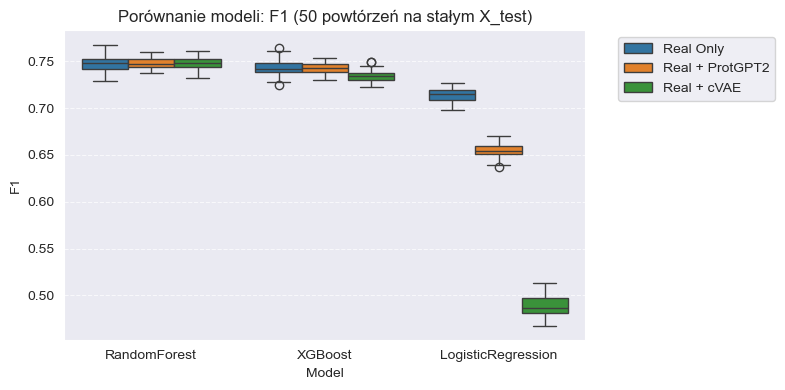

In [46]:
def plot_results(df, metric='F1'):
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='Model', y=metric, hue='Dataset')
    plt.title(f'Porównanie modeli: {metric} (50 powtórzeń na stałym X_test)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_results(df_stat)

## Deep models

MLP

In [18]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.4), # Regularyzacja
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1) # Brak Sigmoida - BCEWithLogitsLoss
        )

    def forward(self, x):
        return self.net(x)

CNNHybrid

In [19]:
class CNNHybrid(nn.Module):
    def __init__(self, vocab_size, feat_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32, padding_idx=0)
        self.conv = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1)
        )
        self.feat_net = nn.Sequential(
            nn.Linear(feat_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 + 32, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 1)
        )

    def forward(self, seq, feats):
        x = self.embedding(seq).permute(0, 2, 1)
        x = self.conv(x).squeeze(-1)
        f = self.feat_net(feats)
        combined = torch.cat([x, f], dim=1)
        return self.classifier(combined)

ProtBERT MLP

In [20]:
class ProtBERT_MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x, _=None): # _ dla kompatybilności z pętlą (Hybrid wejście)
        return self.net(x)

In [ ]:
def preprocess_sequence(seq):
    seq = seq.upper()
    seq = re.sub(r"[UZOB]", "X", seq)  # rzadkie aminokwasy
    return " ".join(list(seq))

In [ ]:
tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
model_bert = BertModel.from_pretrained("Rostlab/prot_bert")

def get_embeddings(sequences, batch_size=16):
    embeddings = []

    for i in tqdm(range(0, len(sequences), batch_size)):
        batch_seqs = sequences[i:i+batch_size]
        batch_seqs = [preprocess_sequence(seq) for seq in batch_seqs]

        encoded = tokenizer(batch_seqs,
                            return_tensors="pt",
                            padding=True,
                            truncation=True,
                            max_length=512)

        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)

        with torch.no_grad():
            outputs = model_bert(input_ids=input_ids,
                                 attention_mask=attention_mask)

        # (batch, seq_len, hidden_dim)
        hidden_states = outputs.last_hidden_state

        # mean pooling (ignorujemy padding)
        mask = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
        summed = torch.sum(hidden_states * mask, dim=1)
        counts = torch.clamp(mask.sum(dim=1), min=1e-9)
        mean_pooled = summed / counts

        embeddings.append(mean_pooled.cpu().numpy())

    return np.vstack(embeddings)

Training

In [ ]:
def run_deep_experiment(model, train_loader, val_loader, device, lr=0.001, patience=12):
    model.to(device)
    # BCEWithLogitsLoss jest stabilniejszy numerycznie
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5) # L2 Regularization

    best_loss = float('inf')
    best_state = None
    counter = 0

    for epoch in range(200):
        # Faza Treningu
        model.train()
        train_loss = 0
        for seq, feat, labels in train_loader:
            seq, feat, labels = seq.to(device), feat.to(device), labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            logits = model(seq, feat) if not isinstance(model, MLP) and not isinstance(model, ProtBERT_MLP) else model(feat)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Faza Walidacji
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for seq, feat, labels in val_loader:
                seq, feat, labels = seq.to(device), feat.to(device), labels.to(device).unsqueeze(1)
                logits = model(seq, feat) if not isinstance(model, MLP) and not isinstance(model, ProtBERT_MLP) else model(feat)
                val_loss += criterion(logits, labels).item()

        avg_val_loss = val_loss / len(val_loader)

        # Early Stopping check
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_state = model.state_dict()
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            break

    model.load_state_dict(best_state)
    return model

In [ ]:
class AmyloidDataset(Dataset):
    def __init__(self, sequences, features, labels, aa_to_idx, max_len=50):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels.values if hasattr(labels, 'values') else labels, dtype=torch.float32)
        self.sequences = [self._encode(s, aa_to_idx, max_len) for s in sequences]

    def _encode(self, seq, aa_to_idx, max_len):
        # Kodowanie aminokwasów na indeksy z paddingiem
        encoded = [aa_to_idx.get(aa, 0) for aa in str(seq)[:max_len]]
        padding = [0] * (max_len - len(encoded))
        return torch.tensor(encoded + padding, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.features[idx], self.labels[idx]

# Słownik mapowania aminokwasów (standardowy)
amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
aa_to_idx = {aa: i+1 for i, aa in enumerate(amino_acids)}

In [ ]:
# --- PRZYGOTOWANIE EMBEDDINGÓW DLA ZBIORU TESTOWEGO (TYLKO RAZ) ---
print("Generowanie embeddingów ProtBERT dla zbioru testowego...")
X_test_embed = get_embeddings(df_ref.loc[X_test.index, "sequence"].tolist())
X_test_scaled_features = StandardScaler().fit_transform(X_test)
X_test_combined_bert = np.concatenate([X_test_embed, X_test_scaled_features], axis=1)

# Loader dla ProtBERT (Test)
test_ds_bert = AmyloidDataset(df_ref.loc[X_test.index, "sequence"], X_test_combined_bert, y_test, aa_to_idx)
test_loader_bert_final = DataLoader(test_ds_bert, batch_size=64, shuffle=False)

# Standardowy loader dla MLP/CNN (Test) - to już masz
test_ds_standard = AmyloidDataset(df_ref.loc[X_test.index, "sequence"], X_test_scaled_features, y_test, aa_to_idx)
test_loader_standard = DataLoader(test_ds_standard, batch_size=64, shuffle=False)

In [ ]:
results_dl = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# --- GŁÓWNA PĘTLA ---
for data_name, (X_train_curr, y_train_curr) in train_datasets.items():
    print(f"\n" + "="*30)
    print(f"START EKSPERYMENTU DL: {data_name}")
    print("="*30)

    # 1. Przygotowanie sekwencji
    if data_name == "Real Only":
        current_seqs = df_ref.loc[X_train_curr.index, "sequence"]
    elif "ProtGPT2" in data_name:
        current_seqs = pd.concat([df_ref.loc[X_train_ref.index, "sequence"], df_protgpt2["sequence"]])
    elif "cVAE" in data_name:
        current_seqs = pd.concat([df_ref.loc[X_train_ref.index, "sequence"], df_cvae["sequence"]])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_curr)

    # Podział na Train/Val
    idx_tr, idx_val = train_test_split(np.arange(len(y_train_curr)), test_size=0.15, stratify=y_train_curr, random_state=42)

    # 4. ITERACJA PO ARCHITEKTURACH
    deep_models = {
        "MLP": MLP(input_dim=len(selected_features)),
        "CNN-Hybrid": CNNHybrid(vocab_size=len(amino_acids)+1, feat_dim=len(selected_features)),
        "ProtBERT-MLP": ProtBERT_MLP(input_dim=1024 + len(selected_features))
    }

    for m_name, model_obj in deep_models.items():
        print(f"--> Trenowanie {m_name}...")

        if m_name == "ProtBERT-MLP":
            # Przygotowanie danych pod BERT
            X_embed_curr = get_embeddings(current_seqs.tolist())
            X_combined_train = np.concatenate([X_embed_curr, X_train_scaled], axis=1)

            tr_ds = AmyloidDataset(current_seqs.iloc[idx_tr], X_combined_train[idx_tr], y_train_curr.iloc[idx_tr], aa_to_idx)
            vl_ds = AmyloidDataset(current_seqs.iloc[idx_val], X_combined_train[idx_val], y_train_curr.iloc[idx_val], aa_to_idx)

            curr_train_loader = DataLoader(tr_ds, batch_size=32, shuffle=True)
            curr_val_loader = DataLoader(vl_ds, batch_size=64, shuffle=False)
            curr_test_loader = test_loader_bert_final # Używamy BERT-owego testu
        else:
            # Standardowe dane dla MLP/CNN
            tr_ds = AmyloidDataset(current_seqs.iloc[idx_tr], X_train_scaled[idx_tr], y_train_curr.iloc[idx_tr], aa_to_idx)
            vl_ds = AmyloidDataset(current_seqs.iloc[idx_val], X_train_scaled[idx_val], y_train_curr.iloc[idx_val], aa_to_idx)

            curr_train_loader = DataLoader(tr_ds, batch_size=32, shuffle=True)
            curr_val_loader = DataLoader(vl_ds, batch_size=64, shuffle=False)
            curr_test_loader = test_loader_standard # Używamy standardowego testu

        # Trening
        trained_model = run_deep_experiment(model_obj, curr_train_loader, curr_val_loader, device)

        # 5. EWALUACJA (Teraz poza blokiem else, dla każdego modelu)
        trained_model.eval()
        all_probs = []
        all_labels = []

        with torch.no_grad():
            for s_t, f_t, l_t in curr_test_loader:
                s_t, f_t = s_t.to(device), f_t.to(device)

                if m_name in ["MLP", "ProtBERT-MLP"]:
                    logits = trained_model(f_t)
                else:
                    logits = trained_model(s_t, f_t)

                probs = torch.sigmoid(logits).cpu().numpy().flatten()
                all_probs.extend(probs)
                all_labels.extend(l_t.numpy())

        all_probs = np.array(all_probs)
        all_preds = (all_probs > 0.5).astype(int)

        results_dl.append({
            "Dataset": data_name,
            "Model": m_name,
            "AUC": roc_auc_score(all_labels, all_probs),
            "F1": f1_score(all_labels, all_preds),
            "ACC": accuracy_score(all_labels, all_preds)
        })